### This example uses undersampling for a regression dataset, CLUSTER CENTROIDS VERSION

**Undersampling is usually more simple in classification dataset, since no binning needs to be done**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# pip install imblearn
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids

# switch to decimal format in pandas for easier values in describe()
pd.set_option('display.float_format', '{:.2f}'.format)

# load the data
df = pd.read_csv("../houses.csv")
df = df.drop(["id", "date", "zipcode", "lat", "long"], axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.00,2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,2720,8062
3,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,1987,0,1800,7503


### Original target distribution in house dataset

<Axes: xlabel='price', ylabel='Count'>

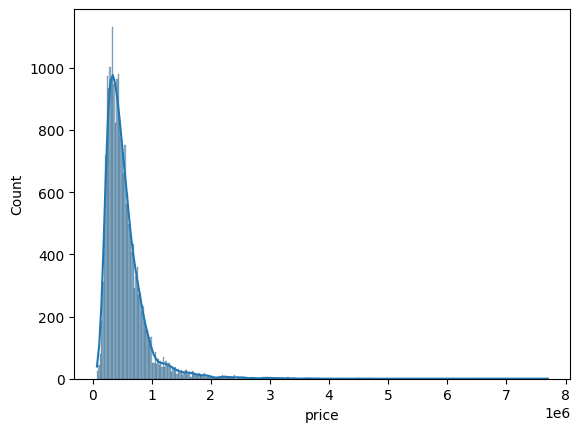

In [3]:
sns.histplot(data=df, x='price', kde=True)

**This dataset has over 21k+ houses, so undersampling can be beneficial**

Isolation Forest, IQR etc. it's possible to use multiple outlier removal tools at once too, but often one is enough (like Isolation Forest)

In [4]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.1) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

# use the inliers as the new DataFrame
df = inliers

Inliers: 19451
Outliers: 2162


<Axes: xlabel='price', ylabel='Count'>

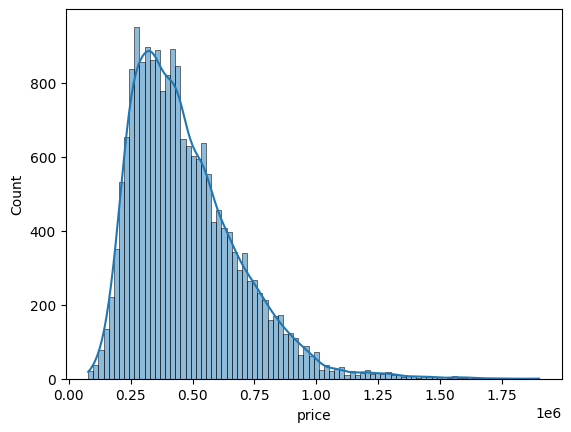

In [5]:
sns.histplot(data=df, x='price', kde=True)

In [6]:
import numpy as np
import pandas as pd

# load dataset
variable = "price"

# Calculate Q1 and Q3, adjust for a more subtle outlier detection
# in this case, we preserve everything from the left side (quantile(0))
# and target the top 30% of the quantile (0.7)
Q1 = df[variable].quantile(0)
Q3 = df[variable].quantile(0.8)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)]
df = df.drop(outliers.index)

<Axes: xlabel='price', ylabel='Count'>

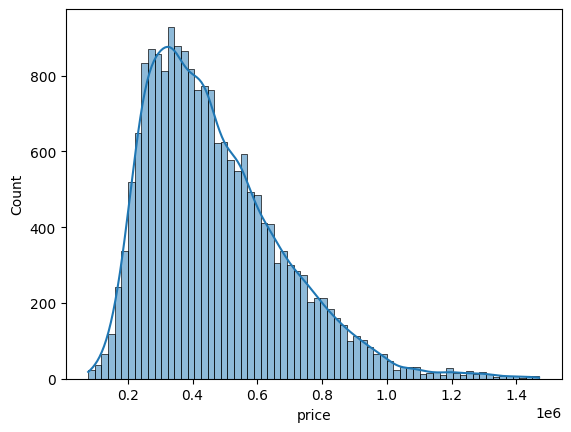

In [7]:
sns.histplot(data=df, x='price', kde=True)

## Undersampling (ClusterCentroids)

Undersampling techniques usually work only on categorical targets, which is a problem, because this is a regression dataset (target is continuous).

In [8]:
# create a temporary variable -> target_binned
# use enough categories to capture most of the trends in the target
target = "price"
df['target_binned'] = pd.cut(df[target], bins=8, labels=False)

<Axes: xlabel='target_binned', ylabel='Count'>

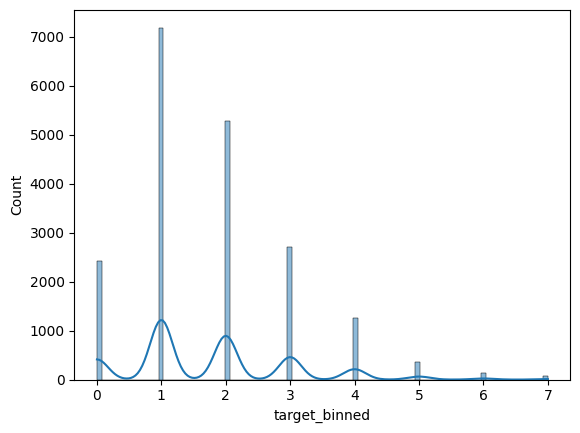

In [9]:
sns.histplot(data=df, x='target_binned', kde=True)

In [10]:
# we need to know how much data each bin contains
# so we know how much data we can reduce eventually
df['target_binned'].value_counts().sort_index()

target_binned
0    2431
1    7187
2    5279
3    2710
4    1250
5     363
6     133
7      64
Name: count, dtype: int64

**Actual undersampling**

In [11]:
# we need X/y -split here
variables = df.drop('target_binned', axis=1).columns

X = df[variables]
y = df['target_binned']

# initialize the undersampler
# it's better to specify a sampling strategy
# since the default sampler removed 95% of our data
strategy = {
    0: 400,
    1: 1200,
    2: 2000,
    3: 1200,
    4: 800,
    5: 300,
    6: 130,
    7: 60

}

# sampler = RandomUnderSampler(sampling_strategy=strategy, random_state=321)
sampler = ClusterCentroids(sampling_strategy=strategy, random_state=321)


# perform undersampling
X_resampled, y_resampled = sampler.fit_resample(X, y)

# reconstruct the dataframe
df_resampled = pd.DataFrame(X_resampled, columns=variables)

# if you still need the binned target for regression
# you can use this, but you can also leave it out
df_resampled['target_binned'] = y_resampled

In [12]:
len(df)

19417

In [13]:
len(df_resampled)

6090

<Axes: xlabel='price', ylabel='Count'>

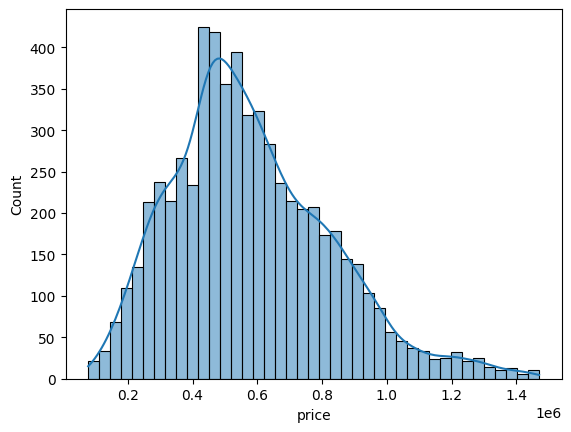

In [14]:
sns.histplot(data=df_resampled, x='price', kde=True)

In [15]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,target_binned
count,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00,19417.00
mean,469920.77,3.31,2.02,1919.61,9939.91,1.47,0.00,0.11,3.40,7.49,1670.72,248.89,1970.98,54.17,1891.10,9196.93,1.75
std,210888.67,0.88,0.68,703.11,12698.05,0.54,0.00,0.49,0.64,0.99,682.44,380.85,29.04,324.32,582.37,10297.11,1.25
min,78000.00,0.00,0.00,380.00,520.00,1.00,0.00,0.00,1.00,4.00,380.00,0.00,1900.00,0.00,460.00,651.00,0.00
25%,310000.00,3.00,1.50,1390.00,5000.00,1.00,0.00,0.00,3.00,7.00,1160.00,0.00,1952.00,0.00,1460.00,5000.00,1.00
50%,429950.00,3.00,2.00,1830.00,7361.00,1.00,0.00,0.00,3.00,7.00,1490.00,0.00,1974.00,0.00,1780.00,7453.00,2.00
75%,588000.00,4.00,2.50,2370.00,9900.00,2.00,0.00,0.00,4.00,8.00,2050.00,500.00,1996.00,0.00,2240.00,9600.00,2.00
max,1470000.00,33.00,5.25,4930.00,327135.00,3.50,0.00,4.00,5.00,11.00,4480.00,2000.00,2015.00,2015.00,4610.00,380279.00,7.00


In [16]:
df_resampled.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,target_binned
count,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00
mean,581731.71,3.28,2.18,2223.11,16301.99,1.52,0.00,0.12,3.27,7.69,1932.21,290.81,1972.63,98.87,2142.17,14159.24,2.41
std,245038.82,0.80,0.59,736.14,20584.17,0.47,0.00,0.48,0.53,1.14,744.22,380.56,24.84,418.16,611.23,16656.12,1.43
min,78000.00,1.00,0.00,490.00,704.00,1.00,0.00,0.00,1.00,4.00,480.00,0.00,1900.00,0.00,460.00,660.00,0.00
25%,415195.83,3.00,1.75,1640.00,5783.50,1.00,0.00,0.00,3.00,7.00,1345.00,0.00,1957.00,0.00,1660.00,5742.25,1.00
50%,546350.00,3.00,2.25,2170.00,9564.50,1.50,0.00,0.00,3.00,8.00,1730.00,105.00,1975.00,0.00,2040.00,8881.00,2.00
75%,732399.25,4.00,2.50,2726.75,17246.75,2.00,0.00,0.00,3.00,8.00,2444.75,502.75,1992.00,0.00,2560.00,14399.75,3.00
max,1470000.00,8.00,5.00,4930.00,327135.00,3.00,0.00,4.00,5.00,11.00,4480.00,2000.00,2015.00,2015.00,4410.00,380279.00,7.00


In [17]:
df.corr()['price']

price           1.00
bedrooms        0.27
bathrooms       0.41
sqft_living     0.59
sqft_lot        0.06
floors          0.26
waterfront       NaN
view            0.16
condition       0.03
grade           0.61
sqft_above      0.50
sqft_basement   0.19
yr_built        0.06
yr_renovated    0.03
sqft_living15   0.54
sqft_lot15      0.05
target_binned   0.97
Name: price, dtype: float64

In [18]:
df_resampled.corr()['price']

price            1.00
bedrooms         0.39
bathrooms        0.49
sqft_living      0.59
sqft_lot        -0.07
floors           0.32
waterfront        NaN
view             0.17
condition        0.13
grade            0.67
sqft_above       0.52
sqft_basement    0.14
yr_built         0.11
yr_renovated     0.02
sqft_living15    0.53
sqft_lot15      -0.08
target_binned    0.98
Name: price, dtype: float64

**Since we altered the target distribution heavily, we can expect basic statistics like mean, median, standard deviation and variation to change.**

However, correlations are surprisingly close to original! (which is promising) However, they are a bit more different than they were in random undersampling. This might be due to the fact, that cluster centroids uses Kmeans in the background and it's not totally random like random under sampler.

You can also check the phik-matrix before and after resampling etc.

**There are still other undersamplers in imblearn, see documentation:**

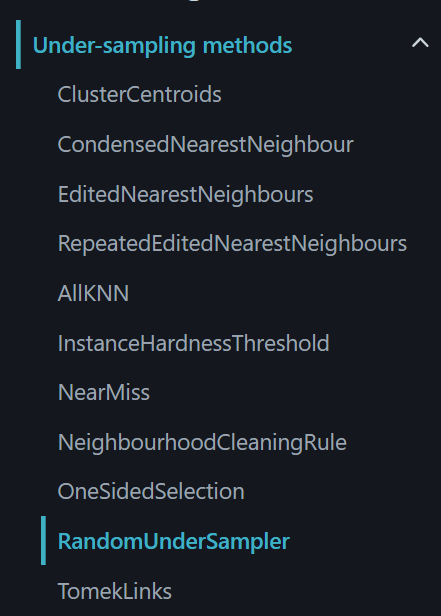